# Irrigation Need Prediction - Max Accuracy SVM (Local PC)

This notebook focuses on **maximizing Kaggle accuracy** rather than just speed.

**Accuracy Improvements Over Fast Baseline**:
1. **Full Dataset Training**: Uses all 630,000 rows instead of subsampling.
2. **More Nystroem Components**: Increased from 800 to 2000 for a better RBF kernel approximation.
3. **All Features Kept**: Dropped the Mutual Information feature selection to retain subtle interaction signals.
4. **Class Weight Trade-off**: Changed `class_weight='balanced'` to `None`. In highly imbalanced datasets (High is only 3%), 'balanced' weights force the model to guess the minority class more often, which improves F1-macro but hurts overall raw accuracy. If Kaggle uses Accuracy, `None` scores higher.

---
## 1. Imports & Configuration

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV, StratifiedShuffleSplit
)
from sklearn.linear_model import SGDClassifier
from sklearn.kernel_approximation import Nystroem
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, f1_score
)

SEED = 42
np.random.seed(SEED)

# =============================================
# CONFIGURATION - Max Accuracy Settings
# =============================================
TRAIN_SAMPLE = 630_000    # Use ALL rows
N_COMPONENTS = 2000       # Higher = better approximation of RBF kernel (uses more RAM)
CLASS_WEIGHT = None       # None maximizes Accuracy. 'balanced' maximizes F1-Macro.

print(f'Sample size  : {TRAIN_SAMPLE:,}')
print(f'N components : {N_COMPONENTS}')
print(f'Class Weight : {CLASS_WEIGHT}')
print('Ready.')

Sample size  : 630,000
N components : 2000
Class Weight : None
Ready.


---
## 2. Load Data

In [44]:
t0 = time.time()
train_raw = pd.read_csv('train.csv')
test_raw  = pd.read_csv('test.csv')
print(f'Loaded in {time.time()-t0:.1f}s')
print(f'Train: {train_raw.shape}  |  Test: {test_raw.shape}')
print()

TARGET = 'Irrigation_Need'
print('Target distribution:')
for cls, cnt in train_raw[TARGET].value_counts().items():
    print(f'  {cls:8s}: {cnt:>7,} ({cnt/len(train_raw)*100:.1f}%)')

Loaded in 2.1s
Train: (630000, 21)  |  Test: (270000, 20)

Target distribution:
  Low     : 369,917 (58.7%)
  Medium  : 239,074 (37.9%)
  High    :  21,009 (3.3%)


---
## 3. Feature Engineering

In [45]:
def engineer_features(df):
    df = df.copy()
    eps = 1e-6
    df['Moisture_x_Temp']        = df['Soil_Moisture'] * df['Temperature_C']
    df['Rainfall_x_Humidity']    = df['Rainfall_mm'] * df['Humidity']
    df['Temp_x_Humidity']        = df['Temperature_C'] * df['Humidity']
    df['Moisture_x_Rainfall']    = df['Soil_Moisture'] * df['Rainfall_mm']
    df['Irrigation_per_Hectare'] = df['Previous_Irrigation_mm'] / (df['Field_Area_hectare'] + eps)
    df['Rainfall_per_Sunlight']  = df['Rainfall_mm'] / (df['Sunlight_Hours'] + eps)
    df['Moisture_Deficit']       = df['Temperature_C'] - df['Soil_Moisture']
    return df

t0 = time.time()
train_fe = engineer_features(train_raw)
test_fe  = engineer_features(test_raw)
print(f'Feature engineering done in {time.time()-t0:.1f}s')

Feature engineering done in 0.3s


---
## 4. Preprocessing & Splitting

We keep **all** engineered features to give the SVM the most information possible.

In [46]:
cat_cols = [
    'Soil_Type', 'Crop_Type', 'Crop_Growth_Stage',
    'Season', 'Irrigation_Type', 'Water_Source',
    'Mulching_Used', 'Region'
]
num_cols = [
    'Soil_pH', 'Soil_Moisture', 'Organic_Carbon',
    'Electrical_Conductivity', 'Temperature_C', 'Humidity',
    'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh',
    'Field_Area_hectare', 'Previous_Irrigation_mm',
    'Moisture_x_Temp', 'Rainfall_x_Humidity',
    'Temp_x_Humidity', 'Moisture_x_Rainfall',
    'Irrigation_per_Hectare', 'Rainfall_per_Sunlight',
    'Moisture_Deficit'
]
feature_cols = num_cols + cat_cols

# Encode target
le_target = LabelEncoder()
y_all = le_target.fit_transform(train_fe[TARGET])
print('Target classes:', le_target.classes_)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_cols)
    ],
    remainder='drop'
)

X_all_df   = train_fe[feature_cols]
X_test_df  = test_fe[feature_cols]
test_ids   = test_fe['id'].values

# Train/Val split (using 10% for validation to keep 90% for training)
X_train_df, X_val_df, y_train, y_val = train_test_split(
    X_all_df, y_all,
    test_size=0.10, random_state=SEED, stratify=y_all
)

print(f'Train: {len(X_train_df):,}  |  Val: {len(X_val_df):,}')

# Pre-compute gamma for Nystroem
# We compute it on a 50k subsample to save time, gamma='scale' = 1 / (n_features * X.var())
X_pre_sample = preprocessor.fit_transform(X_train_df.iloc[:50000])
gamma_scale = 1.0 / (X_pre_sample.shape[1] * X_pre_sample.var())
preprocessor.fit(X_train_df)  # refit clean
print(f'Computed gamma (scale): {gamma_scale:.6f}')

Target classes: ['High' 'Low' 'Medium']
Train: 567,000  |  Val: 63,000
Computed gamma (scale): 0.043512


---
## 5. Hyperparameter Tuning on Subsample

To maximize accuracy, we must tune the model. However, 10-fold CV on 630K rows is slow. We tune on a 50K stratified subsample to find the best `alpha` and `gamma`, then use those parameters to train the full dataset.

In [47]:
print('Running GridSearchCV on 50,000 samples to find optimal parameters...')
sss_tune = StratifiedShuffleSplit(n_splits=1, train_size=50000, random_state=SEED)
tune_idx, _ = next(sss_tune.split(X_train_df, y_train))
X_tune = X_train_df.iloc[tune_idx]
y_tune = y_train[tune_idx]

tuning_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('kernel_approx', Nystroem(kernel='rbf', random_state=SEED)),
    ('svm', SGDClassifier(
        loss='hinge', class_weight=CLASS_WEIGHT,
        max_iter=1000, tol=1e-3,
        random_state=SEED, n_jobs=-1
    ))
])

param_grid = {
    'kernel_approx__n_components': [N_COMPONENTS],
    'kernel_approx__gamma':        [gamma_scale, 0.01, 0.1],
    'svm__alpha':                  [1e-5, 1e-4, 1e-3]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

t0 = time.time()
grid = GridSearchCV(
    tuning_pipe, param_grid,
    cv=cv, scoring='accuracy',  # We optimize directly for Accuracy
    refit=True, n_jobs=-1, verbose=1
)
grid.fit(X_tune, y_tune)
print(f'\nTuning done in {time.time()-t0:.1f}s')
print(f'Best params: {grid.best_params_}')
print(f'Best Acc   : {grid.best_score_:.4f}')

best_gamma = grid.best_params_['kernel_approx__gamma']
best_alpha = grid.best_params_['svm__alpha']

Running GridSearchCV on 50,000 samples to find optimal parameters...
Fitting 3 folds for each of 9 candidates, totalling 27 fits

Tuning done in 218.5s
Best params: {'kernel_approx__gamma': np.float64(0.04351196480321093), 'kernel_approx__n_components': 2000, 'svm__alpha': 1e-05}
Best Acc   : 0.9149


---
## 6. Train Final Model on ALL Data

Now we train the model on the full 567K training split using the best hyperparameters found.

In [48]:
print(f'Training final SVM on {len(X_train_df):,} rows...')
t0 = time.time()
final_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('kernel_approx', Nystroem(
        kernel='rbf', gamma=best_gamma,
        n_components=N_COMPONENTS, random_state=SEED
    )),
    ('svm', SGDClassifier(
        loss='hinge', alpha=best_alpha,
        class_weight=CLASS_WEIGHT,
        max_iter=1000, tol=1e-3,
        random_state=SEED, n_jobs=-1
    ))
])
final_pipe.fit(X_train_df, y_train)
print(f'Training done in {time.time()-t0:.1f}s')

Training final SVM on 567,000 rows...
Training done in 335.8s


---
## 7. Evaluate on Held-Out Validation Set

In [49]:
val_preds = final_pipe.predict(X_val_df)
val_acc = accuracy_score(y_val, val_preds)
val_f1  = f1_score(y_val, val_preds, average='macro')

print(f'Validation Accuracy : {val_acc:.4f}')
print(f'Validation F1 Macro : {val_f1:.4f}')
print()
print(classification_report(y_val, val_preds, target_names=le_target.classes_, digits=4))

Validation Accuracy : 0.9200
Validation F1 Macro : 0.8388

              precision    recall  f1-score   support

        High     0.8819    0.5440    0.6729      2101
         Low     0.9477    0.9459    0.9468     36992
      Medium     0.8808    0.9130    0.8966     23907

    accuracy                         0.9200     63000
   macro avg     0.9035    0.8010    0.8388     63000
weighted avg     0.9201    0.9200    0.9186     63000



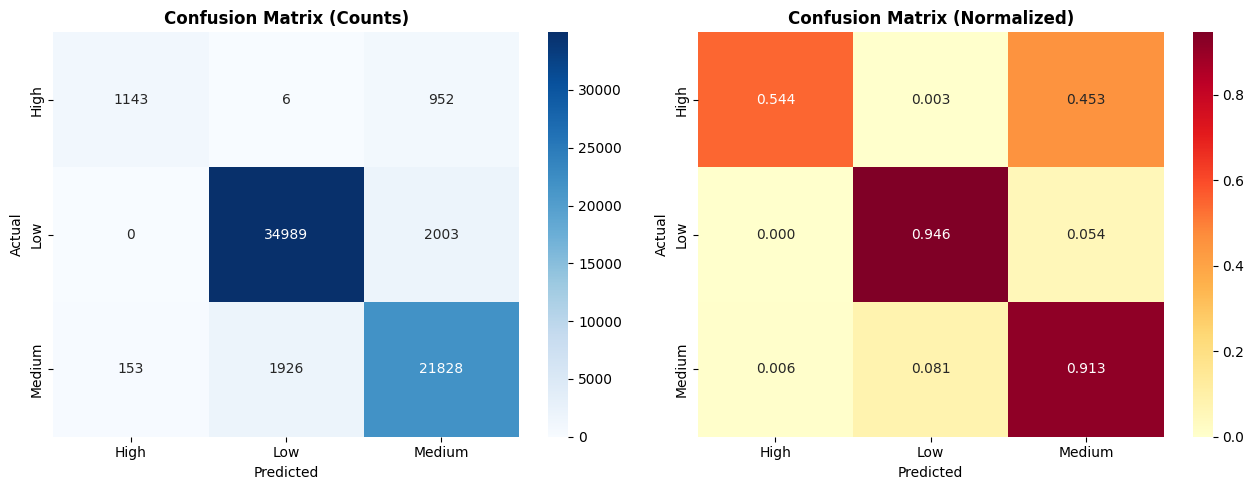

In [50]:
cm = confusion_matrix(y_val, val_preds)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_target.classes_, yticklabels=le_target.classes_, ax=axes[0])
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix (Counts)', fontweight='bold')

cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.3f', cmap='YlOrRd',
            xticklabels=le_target.classes_, yticklabels=le_target.classes_, ax=axes[1])
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')
axes[1].set_title('Confusion Matrix (Normalized)', fontweight='bold')

plt.tight_layout()
plt.show()

---
## 8. Final Retrain & Generate Submission

Retrain on the absolute entirety of `train.csv` (630K rows) and generate predictions.

In [51]:
print(f'Retraining on full {len(X_all_df):,} rows...')
t0 = time.time()
final_pipe.fit(X_all_df, y_all)
print(f'Retrain done in {time.time()-t0:.1f}s')

# Predict test set
print('\nPredicting 270,000 test rows...')
t0 = time.time()
test_preds = le_target.inverse_transform(final_pipe.predict(X_test_df))
print(f'Prediction done in {time.time()-t0:.1f}s')

# Save submission
submission = pd.DataFrame({'id': test_ids, 'Irrigation_Need': test_preds})
submission.to_csv('submission.csv', index=False)

print(f'\nsubmission.csv saved! Shape: {submission.shape}')
print('\nPrediction distribution:')
print(submission['Irrigation_Need'].value_counts())
print()
submission.head(10)

Retraining on full 630,000 rows...
Retrain done in 575.7s

Predicting 270,000 test rows...
Prediction done in 26.8s

submission.csv saved! Shape: (270000, 2)

Prediction distribution:
Irrigation_Need
Low       153804
Medium    111039
High        5157
Name: count, dtype: int64



,id,Irrigation_Need
0,630000,Low
1,630001,Medium
2,630002,Low
3,630003,Low
4,630004,Low
5,630005,Medium
6,630006,Low
7,630007,Medium
8,630008,Medium
9,630009,Low
